# Домашнее задание: Physics-Informed Neural Networks (PINNs)

В этой домашней работе мы:

- Решим **прямую задачу**: получим решение уравнения теплопроводности
- Решим **обратную задачу**: восстановим функцию источника тепла из решения прямой задачи и из точного решения.

---

## Задача: Уравнение теплопроводности

Рассмотрим 1D уравнение теплопроводности:

$$
\frac{\partial u}{\partial t} = \frac{\partial^2 u}{\partial x^2} + \cos(2 \pi x), \quad x \in [0, 1], \ t \ge 0
$$

Начальные условия: $u(x, 0) = \sin^2(3 \pi x)$  
Граничные условия: $\left. \frac{\partial u(x, t)}{\partial x} \right|_{x=0} = \left. \frac{\partial u(x, t)}{\partial x} \right|_{x=1} = 0$


In [16]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

## Класс модели PINN


In [6]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            # your_code_here
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1),
        )

    def forward(self, x):
        return self.model(x)

Выполнение уравнения


In [7]:
def pde_residual(model, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    inputs = torch.cat([x, t], dim=1)
    u = model(inputs)

    # your_code_here
    cos_2_pi_x = torch.cos(2 * np.pi * x)

    u_t = grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    return u_t - u_xx - cos_2_pi_x, cos_2_pi_x


def analytical_solution(x, t):
    return (
        1
        / 2
        * (
            -torch.exp(-4 * np.pi**2 * t) * torch.cos(2 * np.pi * x) / (2 * np.pi**2)
            + (2 * (np.pi) ** 2 + torch.cos(2 * np.pi * x)) / (2 * np.pi**2)
            - torch.exp(-36 * np.pi**2 * t) * torch.cos(6 * np.pi * x)
        )
    )

## **Прямая задача (Forward Problem)**

В прямой задаче решается классическая задача Коши для одномерного уравнения теплопроводности. Источник тепла известен.

Хотим найти функцию $u(x, t)$, удовлетворяющую начальным, граничным условиям и уравнению теплопроводности.

#### Метод:

- Нейросеть $u_\theta(x, t)$ обучается за счёт минимизации следующей функции потерь:

$$
\mathcal{L}_{\text{Total}} = \mathcal{L}_{\text{IC}} + \mathcal{L}_{\text{BC}} + \mathcal{L}_{\text{PDE}}
$$

где

$$
\mathcal{L}_{\text{IC}} = \frac{1}{N_{\text{IC}}} \sum_{i=1}^{N_{\text{IC}}} \left(u_\theta(x_i, 0) - \sin^2(3 \pi x)\right)^2
$$

$$
\mathcal{L}_{\text{BC}} = \frac{1}{N_{\text{BC}}} \sum_{i=1}^{N_{\text{BC}}} \left(\left. \left( \frac{\partial u_\theta(x_i, t_i)}{\partial x} \right|_{x=0}\right)^2 + \left. \left(\frac{\partial u_\theta(x_i, t_i)}{\partial x} \right|_{x=1} \right)^2\right)
$$

$$
\mathcal{L}_{\text{PDE}} = \frac{1}{N_{\text{PDE}}} \sum_{i=1}^{N_{\text{PDE}}} \left( \frac{\partial u_\theta}{\partial t}(x_i, t_i) - \frac{\partial^2 u_\theta}{\partial x^2}(x_i, t_i) - \cos(2 \pi x)\right)^2
$$


### Обучение Forward PINN (2 балла)


Обучите Forward PINN и восстановите $u(x,t)$, сравните его с точным решением. Обратите внимание, что в этом пункте для обучения PINN запрещено использовать аналитическое решение. Модель не должна знать ничего кроме уравнений и условий к нему.


In [30]:
def initial_condition(x):
    return torch.sin(3 * np.pi * x) ** 2


def boundary_condition(t):
    return torch.zeros_like(t)


def train_forward(model, n_ic=100, n_bc=100, n_pde=5000, epochs=3000, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5000, gamma=0.5)

    # your_code_here
    x_ic = torch.rand(n_ic, 1).to(device)
    t_ic = torch.zeros_like(x_ic).to(device)
    u_ic = initial_condition(x_ic).to(device)

    # t масштабируем от 0 до 10
    t_bc = torch.rand(n_bc, 1).mul(10).to(device)
    x_bc_0 = torch.zeros_like(t_bc, requires_grad=True).to(device)
    x_bc_1 = torch.ones_like(t_bc, requires_grad=True).to(device)

    x_pde = torch.rand(n_pde, 1).to(device)
    t_pde = torch.rand(n_pde, 1).mul(10).to(device)

    losses = []

    # Создаем прогресс-бар с tqdm
    pbar = tqdm(range(epochs), desc="Training")

    for epoch in pbar:
        optimizer.zero_grad()

        # IC loss
        u_ic_pred = model(torch.cat([x_ic, t_ic], dim=1))
        loss_ic = nn.MSELoss()(u_ic_pred, u_ic)

        # BC loss
        u_bc_0 = model(torch.cat([x_bc_0, t_bc], dim=1))
        u_bc_0_x = grad(u_bc_0, x_bc_0, grad_outputs=torch.ones_like(u_bc_0), create_graph=True)[0]
        u_bc_1 = model(torch.cat([x_bc_1, t_bc], dim=1))
        u_bc_1_x = grad(u_bc_1, x_bc_1, grad_outputs=torch.ones_like(u_bc_1), create_graph=True)[0]
        loss_bc = nn.MSELoss()(u_bc_0_x, boundary_condition(t_bc)) + nn.MSELoss()(u_bc_1_x, boundary_condition(t_bc))

        # PDE residual loss
        res_pde, _ = pde_residual(model, x_pde, t_pde)
        loss_pde = torch.mean(res_pde**2)

        loss = loss_ic + loss_bc + loss_pde
        loss.backward()
        optimizer.step()
        scheduler.step()

        if epoch % 100 == 0:
            pbar.set_postfix({
                'Loss': f'{loss.item():.5f}',
                'IC': f'{loss_ic.item():.5f}',
                'BC': f'{loss_bc.item():.5f}',
                'PDE': f'{loss_pde.item():.5f}'
            })
        losses.append(loss.item())

    return losses

Training:   0%|          | 0/17000 [00:00<?, ?it/s]

Training: 100%|██████████| 17000/17000 [05:27<00:00, 51.84it/s, Loss=0.00103, IC=0.00089, BC=0.00001, PDE=0.00013]


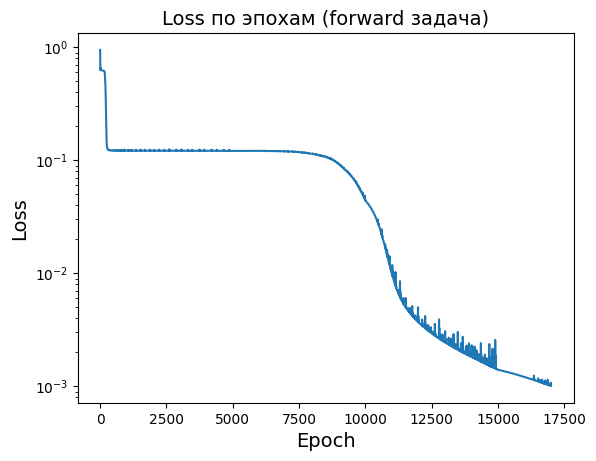

In [31]:
model_forward = PINN().to(device)

losses_forward = train_forward(model_forward, epochs=17000)

plt.plot(losses_forward)
plt.title("Loss по эпохам (forward задача)", fontsize=14)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Loss", fontsize=14)
plt.yscale("log")
plt.show()

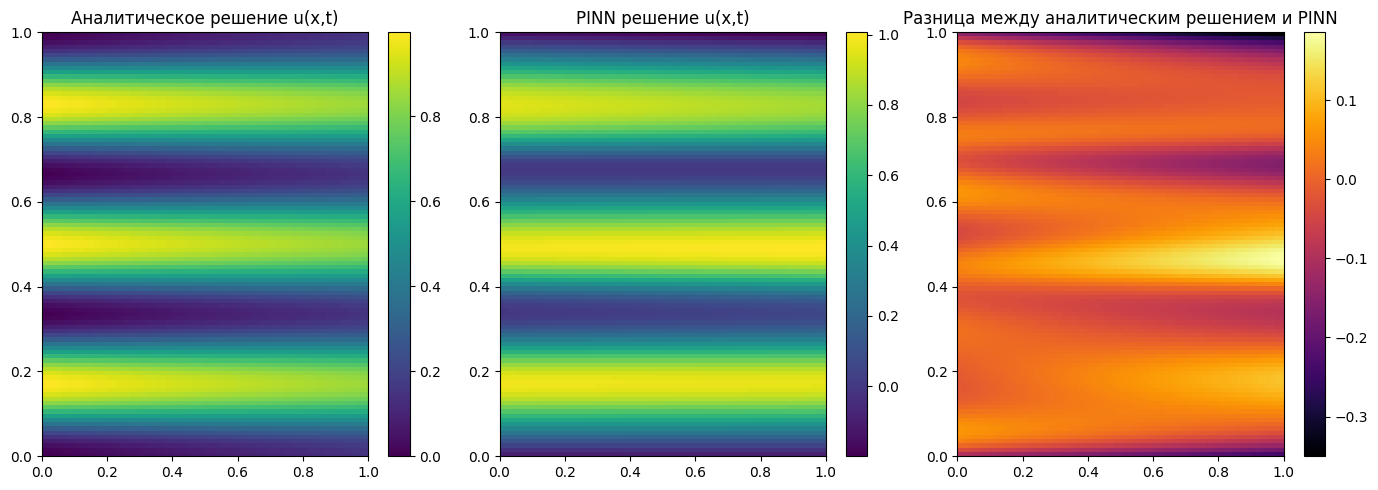

In [42]:
# Создание сетки
x_grid = torch.linspace(0, 1, 100).reshape(-1, 1)
t_grid = torch.linspace(0, 0.001, 100).reshape(-1, 1)
x_mesh, t_mesh = torch.meshgrid(x_grid.squeeze(), t_grid.squeeze(), indexing="ij")
x_flat = x_mesh.reshape(-1, 1).to(device)
t_flat = t_mesh.reshape(-1, 1).to(device)

# Аналитическое решение
u_exact = analytical_solution(x_flat, t_flat).cpu().detach().numpy().reshape(100, 100)

# PINN решение
with torch.no_grad():
    u_pred = model_forward(torch.cat([x_flat, t_flat], dim=1)).cpu().numpy().reshape(100, 100)

# Визуализация
fig, axs = plt.subplots(1, 3, figsize=(14, 5))

c1 = axs[0].imshow(u_exact, extent=[0, 1, 0, 1], origin="lower", aspect="auto", cmap="viridis")
axs[0].set_title("Аналитическое решение u(x,t)")
fig.colorbar(c1, ax=axs[0])

c2 = axs[1].imshow(u_pred, extent=[0, 1, 0, 1], origin="lower", aspect="auto", cmap="viridis")
axs[1].set_title("PINN решение u(x,t)")
fig.colorbar(c2, ax=axs[1])

c3 = axs[2].imshow(u_pred - u_exact, extent=[0, 1, 0, 1], origin="lower", aspect="auto", cmap="inferno")
axs[2].set_title("Разница между аналитическим решением и PINN")
fig.colorbar(c3, ax=axs[2])

plt.tight_layout()
plt.show()

## **Обратная задача (Inverse Problem)**

В обратной задаче предполагается, что функция источника тепла неизвестна, и ее необходимо восстановить.

У нас есть наблюдаемые значения функции $u(x, t)$ в ограниченном числе точек: $$\{(x_i, t_i, u_i^{\text{obs}})\}_{i=1}^{N_{\text{obs}}}$$

Хотим восстановить $f(x)$ по наблюдаемым данным.

#### Метод:

Обучаем нейросеть $u_\theta(x, t)$ и оптимизируем параметр $f(x)$, минимизируя:

$$
\mathcal{L}_{\text{Total}} = \mathcal{L}_{\text{data}} + \mathcal{L}_{\text{PDE}}
$$

где

$$
\mathcal{L}_{\text{data}} = \frac{1}{N_{\text{obs}}} \sum_{i=1}^{N_{\text{obs}}} \left(u_\theta(x_i, t_i) - u_i^{\text{obs}}\right)^2
$$

$$
\mathcal{L}_{\text{PDE}} = \frac{1}{N_{\text{PDE}}} \sum_{i=1}^{N_{\text{PDE}}} \left( \frac{\partial u_\theta}{\partial t}(x_i, t_i) - \frac{\partial^2 u_\theta}{\partial x^2}(x_i, t_i) - f(x)\right)^2
$$


### Обучение Inverse PINN на основе аналитического результата (4 балла)


Обучите нейронную сеть восстанавливать $f(x)$ из аналитического решения. Можете пользоваться любыми хаками и улучшениями, но главное -- не показывать нейронной сети информацию об $f(x)$.
P.S. возможно, вам потребуется поменять архитектуру нейронной сети, чтобы на выходе помимо $u(x,t)$ выдавалась $f(x)$. Можете пойти и другим путем, например, создать отдельную маленькую нейронную сеть для $f(x)$, которая будет принимать на вход, соответственно, только $x$. Feel free to experiment


In [57]:
def generate_data_points(n_obs, n_pde):
    x_obs = torch.rand(n_obs, 1)
    t_obs = torch.rand(n_obs, 1)
    x_pde = torch.rand(n_pde, 1)
    t_pde = torch.rand(n_pde, 1)
    return x_obs, t_obs, x_pde, t_pde

In [138]:
class InversePINN(nn.Module):
    def __init__(self):
        super().__init__()
        # Основная сеть для u(x,t)
        self.u_network = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1),
            nn.Tanh(),
        )
        # Сеть для f(x)
        self.f_network = nn.Sequential(
            nn.Linear(1, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1),
            nn.Tanh(),
        )

    def forward(self, x, t):
        inputs = torch.cat([x, t], dim=1)
        u = self.u_network(inputs)
        f = self.f_network(x)
        return u, f

In [96]:
def pde_residual_inverse(model, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    
    u, f = model(x, t)
    
    u_t = grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    
    return u_t - u_xx - f  # Используем предсказанную f(x)

In [163]:
def train_inverse(model, n_obs=20000, n_pde=10000, epochs=3000, lr=1e-4, lambda_reg=1e-5):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.8)

    x_obs, t_obs, x_pde, t_pde = generate_data_points(n_obs, n_pde)
    x_obs = x_obs.to(device)
    t_obs = t_obs.to(device)
    x_pde = x_pde.to(device)
    t_pde = t_pde.to(device)

    u_obs = analytical_solution(x_obs, t_obs).detach().to(device)

    losses = []

    pbar = tqdm(range(epochs), desc="Training")
    for epoch in pbar:
        optimizer.zero_grad()
        reg = 0.0
        # Data loss
        u_pred, _ = model(x_obs, t_obs)
        loss_data = nn.MSELoss()(u_pred, u_obs)

        # PDE loss
        res_pde = pde_residual_inverse(model, x_pde, t_pde)
        loss_pde = torch.mean(res_pde**2)

        # Регуляризация "вручную", т.к.
        # weight_decay в Adam применяется ко всем параметрам модели
        for param in model.f_network.parameters():
            reg += torch.norm(param, p=2) ** 2

        loss = loss_data*1000 + loss_pde + lambda_reg * reg
        loss.backward()
        optimizer.step()
        scheduler.step()

        if epoch % 100 == 0:
            pbar.set_postfix({
                'Loss': f'{loss.item():.5f}',
                'Data': f'{loss_data.item():.5f}',
                'PDE': f'{loss_pde.item():.5f}',
                'LR': f'{scheduler.get_last_lr()[0]:.5e}'
            })
    
        losses.append(loss.item())

    return losses

#### Запуск и визуализация результатов


Визуализируйте результаты, нарисуйте на одном графике $f(x)$, полученную при помощи PINN и сравните его с точной функцией источника тепла $f(x) = \cos(2 \pi x)$.


In [165]:
# your_code_here
model_inverse = InversePINN().to(device)
losses= train_inverse(model_inverse, epochs=10000, lambda_reg=1e-6, lr=1e-2)

Training:   0%|          | 0/10000 [00:00<?, ?it/s]

Training: 100%|██████████| 10000/10000 [03:52<00:00, 42.95it/s, Loss=0.21778, Data=0.00022, PDE=0.00059, LR=1.34218e-03]


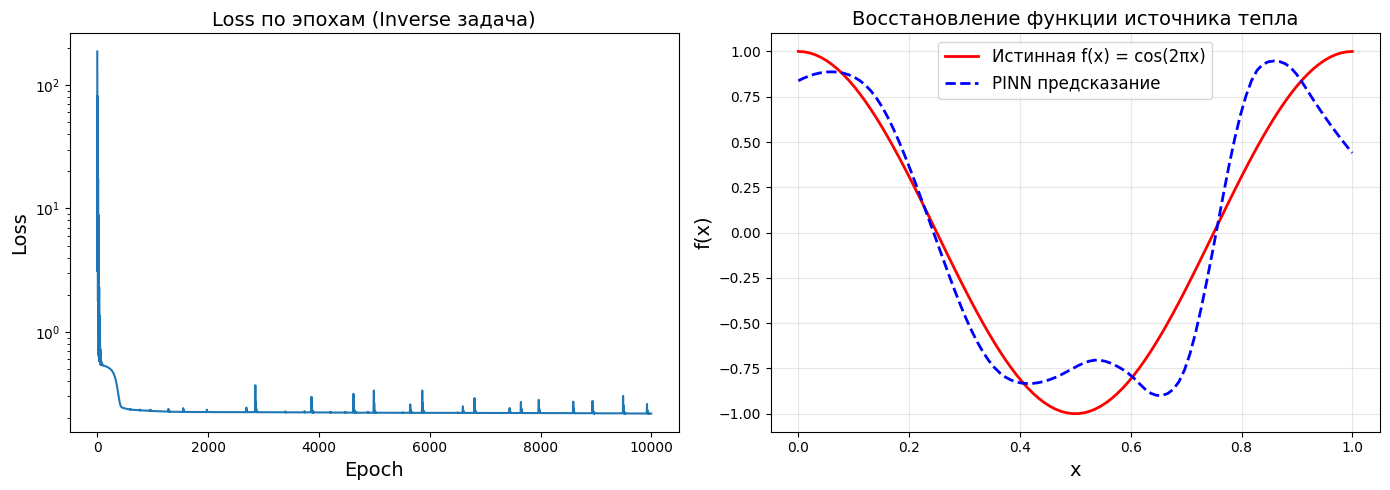

In [166]:
# Визуализация
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.yscale("log")
plt.title("Loss по эпохам (Inverse задача)", fontsize=14)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Loss", fontsize=14)

plt.subplot(1, 2, 2)
x_true = torch.linspace(0, 1, 100)
f_true = torch.cos(2 * np.pi * x_true)
plt.plot(x_true, f_true, 'r-', label='Истинная f(x) = cos(2πx)', linewidth=2)

# Показываем последнее предсказание
x_test = torch.linspace(0, 1, 100).reshape(-1, 1).to(device)
t_test = torch.zeros_like(x_test).to(device)
with torch.no_grad():
    _, f_pred = model_inverse(x_test, t_test)
plt.plot(x_test.cpu(), f_pred.cpu(), 'b--', label='PINN предсказание', linewidth=2)

plt.title("Восстановление функции источника тепла", fontsize=14)
plt.xlabel("x", fontsize=14)
plt.ylabel("f(x)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Inverse PINN на основе ответов Forward PINN (4 балла)


Обучите обратный PINN на основе ответов Forward PINN. Соответственно, Forward PINN знает об источнике тепла, а обратный PINN пытается его восстановить.


In [167]:
# your_code_here
def train_hybrid(model_f, model, n_obs=20000, n_pde=10000, epochs=3000, lr=1e-4, lambda_reg=1e-5):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.8)

    x_obs, t_obs, x_pde, t_pde = generate_data_points(n_obs, n_pde)
    x_obs = x_obs.to(device)
    t_obs = t_obs.to(device)
    x_pde = x_pde.to(device)
    t_pde = t_pde.to(device)

    # Вот главное отличие от train_inverse:
    # Используем модель_f (прямую) для получения u_obs
    with torch.no_grad():
        u_obs = model_f(torch.cat([x_obs, t_obs], dim=1))

    losses = []

    pbar = tqdm(range(epochs), desc="Training")
    for epoch in pbar:
        optimizer.zero_grad()
        reg = 0.0
        # Data loss
        u_pred, _ = model(x_obs, t_obs)
        loss_data = nn.MSELoss()(u_pred, u_obs)

        # PDE loss
        res_pde = pde_residual_inverse(model, x_pde, t_pde)
        loss_pde = torch.mean(res_pde**2)

        # Регуляризация "вручную", т.к.
        # weight_decay в Adam применяется ко всем параметрам модели
        for param in model.f_network.parameters():
            reg += torch.norm(param, p=2) ** 2

        loss = loss_data*50 + loss_pde + lambda_reg * reg
        loss.backward()
        optimizer.step()
        scheduler.step()

        if epoch % 100 == 0:
            pbar.set_postfix({
                'Loss': f'{loss.item():.6f}',
                'Data': f'{loss_data.item():.6f}',
                'PDE': f'{loss_pde.item():.6f}',
                'LR': f'{scheduler.get_last_lr()[0]:.4e}'
            })
    
        losses.append(loss.item())

    return losses

In [168]:
# your_code_here
model_hybrid = InversePINN().to(device)
losses_hybrid = train_hybrid(model_forward, model_hybrid, epochs=10000, lambda_reg=1e-6, lr=1e-2)

Training: 100%|██████████| 10000/10000 [09:11<00:00, 18.13it/s, Loss=0.081103, Data=0.001594, PDE=0.001327, LR=1.3422e-03] 


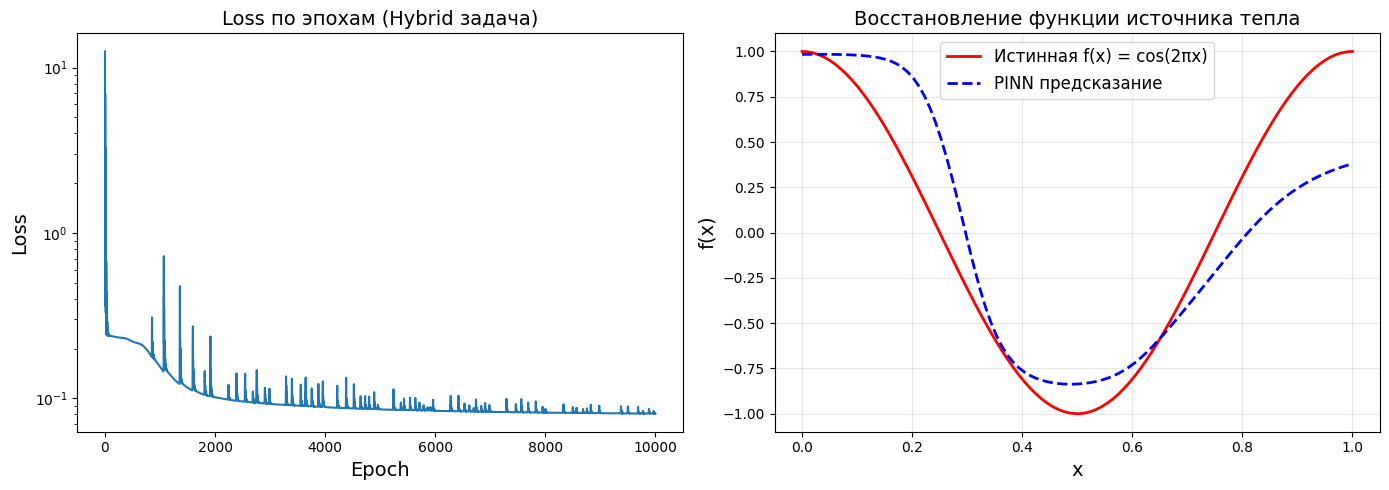

In [169]:
# Визуализация
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(losses_hybrid)
plt.yscale("log")
plt.title("Loss по эпохам (Hybrid задача)", fontsize=14)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Loss", fontsize=14)

plt.subplot(1, 2, 2)
x_true = torch.linspace(0, 1, 100)
f_true = torch.cos(2 * np.pi * x_true)
plt.plot(x_true, f_true, 'r-', label='Истинная f(x) = cos(2πx)', linewidth=2)

# Показываем последнее предсказание
x_test = torch.linspace(0, 1, 100).reshape(-1, 1).to(device)
t_test = torch.zeros_like(x_test).to(device)
with torch.no_grad():
    _, f_pred = model_hybrid(x_test, t_test)
plt.plot(x_test.cpu(), f_pred.cpu(), 'b--', label='PINN предсказание', linewidth=2)

plt.title("Восстановление функции источника тепла", fontsize=14)
plt.xlabel("x", fontsize=14)
plt.ylabel("f(x)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()